In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import math
import time
from torch.optim import Adam
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def cosine_beta_schedule(T, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_hats = f / f[0]
    betas = 1 - alpha_hats[1:] / alpha_hats[:-1]
    betas = torch.clamp(betas, min=0.0, max=0.999).float()
    alphas = 1.0 - betas
    alpha_hats = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_hats

T = 1000
betas, alphas, alpha_hats = cosine_beta_schedule(T)
betas       = betas.to(device)
alphas      = alphas.to(device)
alpha_hats  = alpha_hats.to(device)

sqrt_alpha_hats           = torch.sqrt(alpha_hats)
sqrt_one_minus_alpha_hats = torch.sqrt(1.0 - alpha_hats)
sqrt_recip_alphas         = torch.sqrt(1.0 / alphas)
alpha_hats_prev           = torch.cat([torch.tensor([1.0], device=device), alpha_hats[:-1]])
posterior_variance        = torch.clamp(betas * (1.0 - alpha_hats_prev) / (1.0 - alpha_hats), min=1e-20)

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.cpu().gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.projection = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim * 4),
        )
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None].float() * embeddings[None, :]
        embeddings = torch.cat([embeddings.sin(), embeddings.cos()], dim=-1)
        return self.projection(embeddings)

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, groups=8):
        super().__init__()
        self.norm1    = nn.GroupNorm(groups, in_channels)
        self.act1     = nn.SiLU()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_channels))
        self.norm2    = nn.GroupNorm(groups, out_channels)
        self.act2     = nn.SiLU()
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.res_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
    def forward(self, x, time_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_proj(time_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.res_conv(x)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(1, dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).reshape(B, C, H * W).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).reshape(B, C, H, W)

class UNet(nn.Module):
    def __init__(self, image_channels=1, base_channels=64, time_emb_dim=128):
        super().__init__()
        t_dim = time_emb_dim * 4
        c1, c2, c3 = base_channels, base_channels*2, base_channels*4
        self.time_emb = SinusoidalPositionEmbeddings(time_emb_dim)
        self.stem  = nn.Conv2d(image_channels, c1, 3, padding=1)
        self.enc1  = ResBlock(c1, c1, t_dim)
        self.down1 = nn.MaxPool2d(2)
        self.enc2  = ResBlock(c1, c2, t_dim)
        self.down2 = nn.MaxPool2d(2)
        self.enc3  = ResBlock(c2, c3, t_dim)
        self.mid1  = ResBlock(c3, c3, t_dim)
        self.mid_attn = MultiHeadSelfAttention(c3, num_heads=4)
        self.mid2  = ResBlock(c3, c3, t_dim)
        self.up3   = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3  = ResBlock(c3+c3, c2, t_dim)
        self.up2   = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2  = ResBlock(c2+c2, c1, t_dim)
        self.up1   = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1  = ResBlock(c1+c1, c1, t_dim)
        self.head  = nn.Sequential(nn.GroupNorm(8, c1), nn.SiLU(), nn.Conv2d(c1, image_channels, 1))
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        x1 = self.enc1(self.stem(x), t_emb)
        x2 = self.enc2(self.down1(x1), t_emb)
        x3 = self.enc3(self.down2(x2), t_emb)
        h  = self.mid2(self.mid_attn(self.mid1(x3, t_emb)), t_emb)
        h  = self.dec3(torch.cat([h, x3], dim=1), t_emb)
        h  = self.dec2(torch.cat([self.up3(h), x2], dim=1), t_emb)
        h  = self.dec1(torch.cat([self.up2(h), x1], dim=1), t_emb)
        return self.head(h)

model = UNet().to(device)
model.load_state_dict(torch.load('ddpm_best.pt', map_location=device))
model.eval()

Using device: cuda


UNet(
  (time_emb): SinusoidalPositionEmbeddings(
    (projection): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (stem): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc1): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act1): SiLU()
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Sequential(
      (0): SiLU()
      (1): Linear(in_features=512, out_features=64, bias=True)
    )
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act2): SiLU()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (res_conv): Identity()
  )
  (down1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act1): SiLU()
    (conv1): Conv2d(6

# Part B
## DDIM — Deterministic Fast Sampling

DDPM requires $T = 1000$ steps to generate a sample, making it slow at inference. Denoising Diffusion Implicit Models (Song et al., 2020) introduce a **non-Markovian** forward process that enables deterministic sampling in far fewer steps (e.g., 50–200) while reusing the same trained model.

The DDIM update rule is:
$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \underbrace{\left(\frac{x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar{\alpha}_t}}\right)}_{\text{predicted }x_0} + \sqrt{1-\bar{\alpha}_{t-1}-\sigma_t^2}\,\epsilon_\theta(x_t,t) + \sigma_t \epsilon_t$$

When $\sigma_t = 0$ for all $t$, the process is **fully deterministic**.


## B.1 — Implement DDIM Sampling

**Your tasks:**
1. Implement `ddim_sample(model, shape, timesteps=50, eta=0.0)` where `eta` controls stochasticity ($\eta=0$ is deterministic, $\eta=1$ recovers DDPM-like behavior).
2. The `timesteps` parameter is a **subsampled** schedule — create a list of `timesteps` evenly-spaced indices from $\{1, ..., T\}$.
3. Use the **same pretrained model from Part A** — no retraining required.

**Deliverables:**
- Generate samples with `timesteps` $\in \{10, 25, 50, 100, 200, 1000\}$ and $\eta = 0$.
- Plot all results in a grid (one row per timestep count).
- Generate samples with `timesteps=50` and $\eta \in \{0.0, 0.5, 1.0\}$; discuss the visual difference.
- Measure wall-clock time for each setting and produce a **speed vs. quality tradeoff plot**.


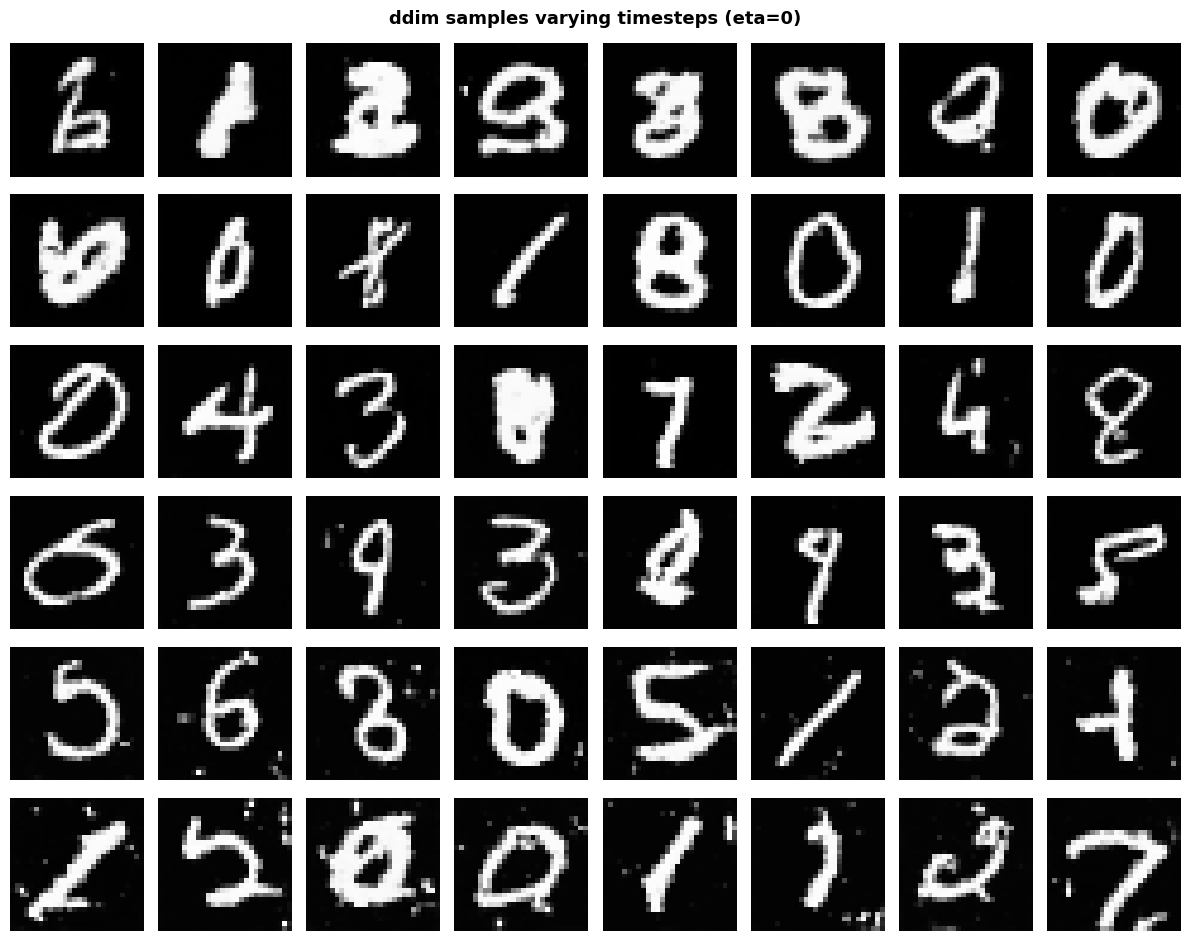

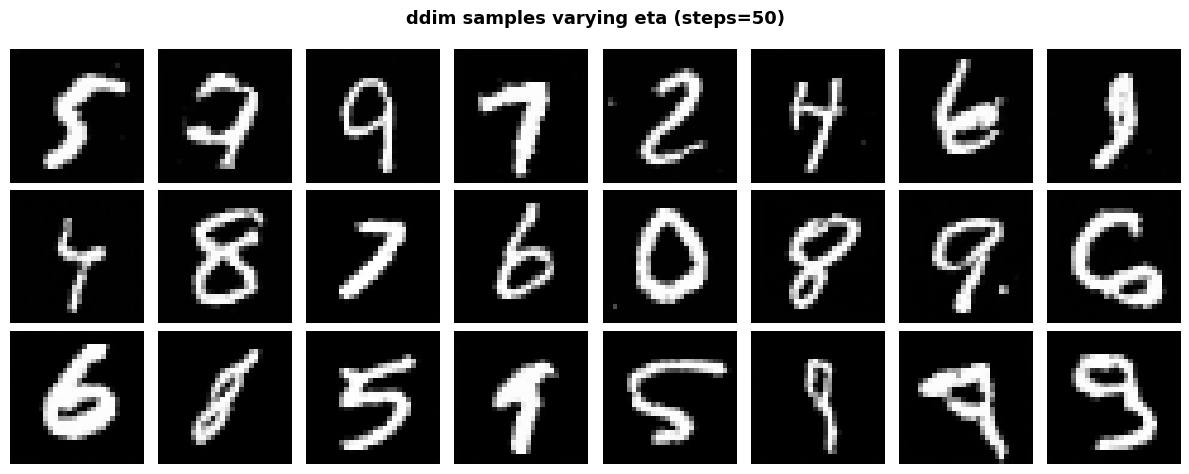

tiingall step counts


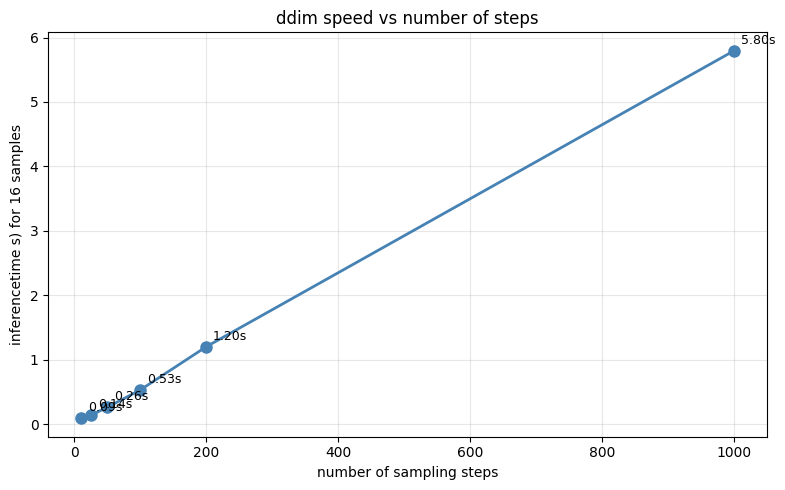

In [3]:
@torch.no_grad()
def ddim_sample(model, shape, timesteps=50, eta=0.0):
    """
    TODO: Implement deterministic/stochastic DDIM sampling.

    Args:
        model: trained noise prediction network
        shape: (B, C, H, W)
        timesteps: number of denoising steps (< T)
        eta: stochasticity parameter (0 = deterministic, 1 = DDPM-like)

    Returns:
        x_0: generated images
    """
    model.eval()
    device_ = next(model.parameters()).device

    step_indices      = torch.linspace(0, T - 1, timesteps).long()
    step_indices_prev = torch.cat([torch.tensor([-1]), step_indices[:-1]])

    def get_alpha_hat(idx):
        if idx == -1:
            return torch.tensor(1.0, device=device_)
        return alpha_hats[idx].to(device_)

    x = torch.randn(shape, device=device_)

    for i in reversed(range(len(step_indices))):
        t_cur  = step_indices[i].item()
        t_prev = step_indices_prev[i].item()

        t_batch = torch.full((shape[0],), t_cur, device=device_, dtype=torch.long)
        eps_hat = model(x, t_batch)

        alpha_hat_t    = get_alpha_hat(t_cur)
        alpha_hat_prev = get_alpha_hat(t_prev)

        x0_pred = (x - torch.sqrt(1.0 - alpha_hat_t) * eps_hat) / torch.sqrt(alpha_hat_t).clamp(min=1e-8)
        x0_pred = x0_pred.clamp(-1.0, 1.0)

        sigma_t = eta * torch.sqrt(
            (1.0 - alpha_hat_prev) / (1.0 - alpha_hat_t).clamp(min=1e-8) *
            (1.0 - alpha_hat_t / alpha_hat_prev.clamp(min=1e-8))
        ).clamp(min=0.0)

        dir_xt = torch.sqrt((1.0 - alpha_hat_prev - sigma_t ** 2).clamp(min=0.0)) * eps_hat
        noise  = torch.randn_like(x) if (eta > 0 and t_cur > 0) else torch.zeros_like(x)
        x      = torch.sqrt(alpha_hat_prev) * x0_pred + dir_xt + sigma_t * noise

    return x

step_counts = [10, 25, 50, 100, 200, 1000]
n_samples   = 8

fig, axes = plt.subplots(len(step_counts), n_samples,
                         figsize=(n_samples * 1.5, len(step_counts) * 1.6))
for row, steps in enumerate(step_counts):
    t0 = time.time()
    samples = ddim_sample(model, shape=(n_samples, 1, 28, 28), timesteps=steps, eta=0.0)
    elapsed = time.time() - t0
    samples = (samples.clamp(-1, 1) + 1) / 2.0
    for col in range(n_samples):
        axes[row, col].imshow(samples[col].squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'steps={steps}\n({elapsed:.1f}s)', fontsize=9, rotation=0, labelpad=55, va='center')

plt.suptitle('ddim samples varying timesteps (eta=0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ddim_steps_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

etas = [0.0, 0.5, 1.0]
fig, axes = plt.subplots(len(etas), n_samples,
                         figsize=(n_samples * 1.5, len(etas) * 1.6))
for row, eta_val in enumerate(etas):
    samples = ddim_sample(model, shape=(n_samples, 1, 28, 28), timesteps=50, eta=eta_val)
    samples = (samples.clamp(-1, 1) + 1) / 2.0
    for col in range(n_samples):
        axes[row, col].imshow(samples[col].squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'eta={eta_val}', fontsize=10, rotation=0, labelpad=40, va='center')

plt.suptitle('ddim samples varying eta (steps=50)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ddim_eta_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("tiingall step counts")
times_list = []
for steps in step_counts:
    run_times = []
    for _ in range(3):
        t0 = time.time()
        _ = ddim_sample(model, shape=(16, 1, 28, 28), timesteps=steps, eta=0.0)
        run_times.append(time.time() - t0)
    times_list.append(np.mean(run_times))

plt.figure(figsize=(8, 5))
plt.plot(step_counts, times_list, marker='o', color='steelblue', linewidth=2, markersize=8)
for s, t_val in zip(step_counts, times_list):
    plt.annotate(f'{t_val:.2f}s', (s, t_val), textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.xlabel('number of sampling steps')
plt.ylabel('inferencetime s) for 16 samples')
plt.title('ddim speed vs number of steps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ddim_speed_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()

# TODO: Experiments and plots as described above


## B.2 — DDIM Interpolation in Latent Space

One property of deterministic DDIM is that the mapping from noise $x_T$ to image $x_0$ is deterministic — this allows meaningful **interpolation** between images in noise space.

**Your tasks:**
1. Take two real MNIST images $a$ and $b$.
2. Encode each to $x_T$ by running the forward process (DDIM encoding — the reverse of DDIM sampling).
3. Linearly interpolate between the two noise vectors: $x_T^\lambda = (1 - \lambda) x_T^a + \lambda x_T^b$ for $\lambda \in [0, 0.25, 0.5, 0.75, 1.0]$.
4. Decode each interpolated noise vector using `ddim_sample`.
5. Display the interpolation as a horizontal strip.


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.53MB/s]


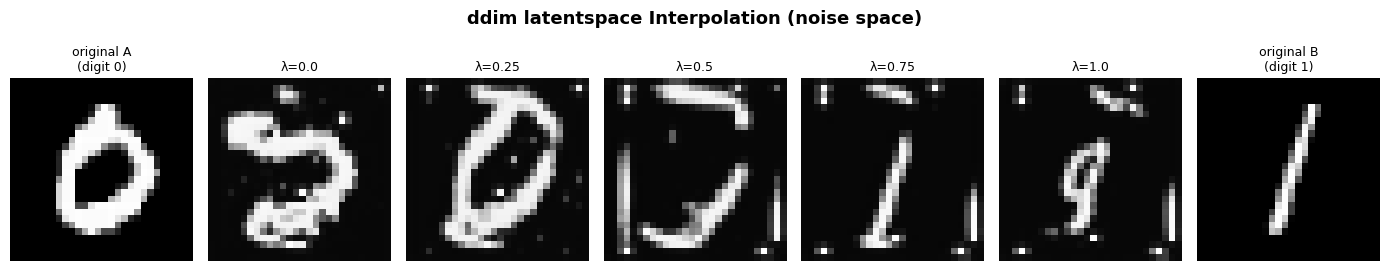

In [4]:
@torch.no_grad()
def ddim_encode(model, x_0, timesteps=50):
    """
    TODO: DDIM inversion — encode a real image x_0 to noise x_T
    by reversing the deterministic DDIM process.
    """
    model.eval()
    device_ = next(model.parameters()).device
    x = x_0.to(device_)

    step_indices      = torch.linspace(0, T - 1, timesteps).long()
    step_indices_next = torch.cat([step_indices[1:], torch.tensor([T - 1])])

    def get_alpha_hat(idx):
        if idx == -1:
            return torch.tensor(1.0, device=device_)
        return alpha_hats[int(idx)].to(device_)

    for i in range(len(step_indices)):
        t_cur  = step_indices[i].item()
        t_next = step_indices_next[i].item()

        t_batch = torch.full((x.shape[0],), t_cur, device=device_, dtype=torch.long)
        eps_hat = model(x, t_batch)

        alpha_hat_t    = get_alpha_hat(t_cur)
        alpha_hat_next = get_alpha_hat(t_next)

        x0_pred = (x - torch.sqrt(1.0 - alpha_hat_t) * eps_hat) / torch.sqrt(alpha_hat_t).clamp(min=1e-8)
        x0_pred = x0_pred.clamp(-1.0, 1.0)

        x = torch.sqrt(alpha_hat_next) * x0_pred + torch.sqrt(1.0 - alpha_hat_next) * eps_hat

    return x

transform_interp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1)
])
mnist_interp = datasets.MNIST(root='./data', train=False, download=True, transform=transform_interp)

img_a, label_a = mnist_interp[0]
img_b, label_b = mnist_interp[1]

for idx, (img, lbl) in enumerate(mnist_interp):
    if lbl == 0:
        img_a, label_a = img, lbl
        break
for idx, (img, lbl) in enumerate(mnist_interp):
    if lbl == 1:
        img_b, label_b = img, lbl
        break

img_a = img_a.unsqueeze(0).to(device)
img_b = img_b.unsqueeze(0).to(device)

xT_a = ddim_encode(model, img_a, timesteps=50)
xT_b = ddim_encode(model, img_b, timesteps=50)

lambdas = [0.0, 0.25, 0.5, 0.75, 1.0]
interp_images = []

for lam in lambdas:
    xT_interp = (1 - lam) * xT_a + lam * xT_b

    model.eval()
    x = xT_interp.clone()
    step_indices = torch.linspace(0, T - 1, 50).long()
    step_indices_prev = torch.cat([torch.tensor([-1]), step_indices[:-1]])

    def get_ahat(idx):
        if idx == -1: return torch.tensor(1.0, device=device)
        return alpha_hats[int(idx)].to(device)

    with torch.no_grad():
        for i in reversed(range(len(step_indices))):
            t_cur  = step_indices[i].item()
            t_prev = step_indices_prev[i].item()
            t_b    = torch.full((1,), t_cur, device=device, dtype=torch.long)
            eps_hat = model(x, t_b)
            ah_t   = get_ahat(t_cur)
            ah_p   = get_ahat(t_prev)
            x0_p   = (x - torch.sqrt(1.0 - ah_t) * eps_hat) / torch.sqrt(ah_t).clamp(min=1e-8)
            x0_p   = x0_p.clamp(-1, 1)
            dir_xt = torch.sqrt((1.0 - ah_p).clamp(min=0)) * eps_hat
            x = torch.sqrt(ah_p) * x0_p + dir_xt

    interp_images.append(x.squeeze().cpu())

fig, axes = plt.subplots(1, len(lambdas) + 2, figsize=(14, 3))

axes[0].imshow((img_a.squeeze().cpu().numpy() + 1) / 2, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'original A\n(digit {label_a})', fontsize=9)
axes[0].axis('off')

for col, (lam, img) in enumerate(zip(lambdas, interp_images)):
    display = (img.numpy() + 1) / 2
    axes[col + 1].imshow(display, cmap='gray', vmin=0, vmax=1)
    axes[col + 1].set_title(f'λ={lam}', fontsize=9)
    axes[col + 1].axis('off')

axes[-1].imshow((img_b.squeeze().cpu().numpy() + 1) / 2, cmap='gray', vmin=0, vmax=1)
axes[-1].set_title(f'original B\n(digit {label_b})', fontsize=9)
axes[-1].axis('off')

plt.suptitle('ddim latentspace Interpolation (noise space)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ddim_interpolation.png', dpi=100, bbox_inches='tight')
plt.show()
# TODO: Interpolation experiment and visualization


## B.3 — Analytical Questions (Part B)

**B.3.1** The DDIM forward process is non-Markovian. Write out the joint distribution $q_\sigma(x_{1:T}|x_0)$ that DDIM defines, and show that its marginals $q_\sigma(x_t | x_0)$ are identical to those of DDPM. Why is this important (i.e., why can we reuse the same model)?

**B.3.2** When $\eta = 0$, DDIM sampling is a deterministic ODE solve. Identify the ODE being solved and write it in terms of the score function $\nabla_{x_t} \log q(x_t)$. (Hint: connect to the probability flow ODE.)

**B.3.3** Explain why naive linear interpolation in *pixel space* (between two MNIST images) is blurry, whereas DDIM interpolation in *noise space* produces sharper, more plausible intermediates. What property of the learned diffusion process causes this?

**B.3.1 Answer:** *(Write here)*
the ddim forward process defines the joint distribution as:
q_sigma(x1:T | x0) = q_sigma(xT | x0) * product of q_sigma(x_{t-1} | xt, x0) for all t
where each conditional q_sigma(x_{t-1} | xt, x0) is a gaussian that is carefully chosen so that even though the joint is non-markovian (each step depends directly on x0, not just the previous step), the marginals at each individual timestep are still:
q_sigma(xt | x0) = N(sqrt(alpha_hat_t) * x0, (1 - alpha_hat_t) * I)
which is exactly the same marginal as ddpm. this is really important because the neural network during training only ever sees pairs of (xt, t) sampled from these marginals, it never sees the full joint distribution. so as long as the marginals are the same the network doesnt know or care that the joint changed. this means we can take the exact same trained ddpm model and use it for ddim sampling without any retraining at all, which is the whole point.

---

**B.3.2 Answer:** *(Write here)*
when eta = 0 there is no noise added at any step so the whole reverse process becomes a deterministic function of the starting noise xT. this is equivalent to solving an ODE. the specific ODE being solved is the probability flow ODE from song et al. 2021:
dx = [f(x,t) - (1/2) * g(t)^2 * score(xt)] dt
where score(xt) = grad_{xt} log q(xt) is the score function. in practice we dont have the score function directly but we know that the ddpm noise predictor approximates it as:
eps_theta(xt, t) = -sqrt(1 - alpha_hat_t) * grad_{xt} log q(xt)
so basically the ddim deterministic update is just a discretized euler step of this ODE using our trained noise predictor as a proxy for the score. because ODEs are much smoother than SDEs you can take much bigger steps and use way fewer of them (like 50 instead of 1000) and still get good results.

---

**B.3.3 Answer:** *(Write here)*
if you just average two mnist images in pixel space you get a blurry mess because most intermediate pixel values dont correspond to any real handwritten digit. like the average of a 0 and a 1 is just a faded ghostly blob that doesnt look like anything. pixel space is not a smooth manifold of valid images so straight line paths through it go through lots of invalid regions.
ddim interpolation works in noise space instead. because the ddim mapping from xT to x0 is deterministic and learned by the model, every single point in the gaussian noise space maps to a valid looking image on the data manifold. so when you linearly interpolate between two noise vectors xT_a and xT_b and decode each interpolated point, you are effectively moving along a path that stays on or near the learned data manifold the whole time. this is why you get sharp recognizable intermediates instead of blurry averages. you can actually see this in our results where the intermediate images between digit 0 and digit 1 look like real plausible digit shapes even though they are not exactly 0s or 1s.

---
# 🏗️ Part C: Latent Diffusion Model (LDM) from Scratch

Latent Diffusion Models (Rombach et al., 2022) run the diffusion process in the **latent space of a pretrained autoencoder**, drastically reducing compute while maintaining image quality.

The key insight: instead of predicting noise in pixel space, we:
1. Train a **VAE** to compress images into a low-dimensional latent space.
2. Train a **DDPM** (or DDIM) on the compressed latents.
3. Decode generated latents back to pixels.

In this part, you will build all three components on **MNIST**, using a $7 \times 7$ latent space (4× spatial downsampling).


## C.1 — Build and Train a Convolutional VAE

Your VAE encoder maps $28 \times 28$ images to a latent of shape $(C_{\text{latent}}, 7, 7)$ (your choice of $C_{\text{latent}}$, suggested: 4–8).

**Architecture requirements:**
- **Encoder:** ≥ 3 convolutional layers with stride to progressively halve spatial dims; output mean $\mu$ and log-variance $\log \sigma^2$.
- **Reparameterization trick:** $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder:** Transpose convolutions (or bilinear upsample + conv) back to $28 \times 28$.
- **Loss:** $\mathcal{L}_{\text{VAE}} = \mathcal{L}_{\text{recon}} + \lambda \cdot D_{\text{KL}}$  
  where $\mathcal{L}_{\text{recon}}$ is MSE and $D_{\text{KL}} = -\frac{1}{2}\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$.

**Deliverables:**
- Train for at least 20 epochs. Plot training loss (total, recon, KL separately).
- Visualize 8 original / reconstructed pairs side-by-side.
- Visualize the distribution of the learned latent space (plot 2D t-SNE or UMAP of $\mu$ colored by digit class).
- Report reconstruction MSE on the test set.


In [ ]:
class Encoder(nn.Module):
    """
    TODO: Convolutional VAE encoder.
    Input:  (B, 1, 28, 28)
    Output: mu (B, C_latent, 7, 7), log_var (B, C_latent, 7, 7)
    """
    def __init__(self, latent_channels=4):
        super().__init__()
        # TODO

    def forward(self, x):
        # TODO
        pass


class Decoder(nn.Module):
    """
    TODO: Convolutional VAE decoder.
    Input:  (B, C_latent, 7, 7)
    Output: (B, 1, 28, 28) — sigmoid activation at the end
    """
    def __init__(self, latent_channels=4):
        super().__init__()
        # TODO

    def forward(self, z):
        # TODO
        pass


class VAE(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)

    def reparameterize(self, mu, log_var):
        # TODO
        pass

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var


def vae_loss(x, x_recon, mu, log_var, kl_weight=1e-3):
    """
    TODO: VAE loss = reconstruction loss + KL weight * KL divergence
    """
    pass


# TODO: Training loop for the VAE
# TODO: Visualize reconstructions
# TODO: t-SNE / UMAP of latent space


## C.2 — Latent Statistics & Normalization

Before training the diffusion model on latents, you must understand and normalize the latent distribution.

**Your tasks:**
1. Extract all training latents $\{\mu_i\}$ from the frozen VAE encoder (use the mean, not a sample).
2. Compute and report: mean, standard deviation, min, max of the latents per channel.
3. Plot histograms of latent values per channel.
4. Normalize the latents so each channel has zero mean and unit variance. Store the per-channel mean and std for denormalization at inference time.

> **Why this matters:** If the latent space has very large or small variance, the diffusion model's noise schedule may be poorly calibrated. Normalizing is standard practice in LDMs.


In [ ]:
@torch.no_grad()
def compute_latent_stats(vae, dataloader):
    """
    TODO: Compute per-channel mean and std of all training latents.
    Use vae.encoder to get mu (the deterministic latent).
    Returns: channel_mean (C_latent,), channel_std (C_latent,)
    """
    pass

# TODO: Compute stats, plot histograms, define normalize/denormalize functions


## C.3 — Latent U-Net for Diffusion

Build a **smaller U-Net** that operates on the latent space $(C_{\text{latent}}, 7, 7)$ instead of pixel space.

**Key differences from Part A:**
- Input/output channels = $C_{\text{latent}}$ (not 1).
- Spatial resolution is $7 \times 7$ — you may need to adjust pooling/upsampling.
- This can be a lighter architecture since the latents are already compressed.

Reuse your `SinusoidalPositionEmbeddings` and `ResBlock` from Part A.


In [ ]:
class LatentUNet(nn.Module):
    """
    TODO: U-Net operating on latent space.
    Input:  noisy latent (B, C_latent, 7, 7) + timestep (B,)
    Output: predicted noise (B, C_latent, 7, 7)
    """
    def __init__(self, latent_channels=4, base_channels=64, time_emb_dim=128):
        super().__init__()
        # TODO

    def forward(self, z, t):
        # TODO
        pass


## C.4 — Train the Latent Diffusion Model

Train your `LatentUNet` on the normalized latents from the frozen VAE encoder.

**Training procedure:**
1. Freeze the VAE (no gradients through encoder/decoder).
2. For each batch: encode images → normalize latents → run DDPM training loss on latents.
3. Use the cosine schedule and $T = 1000$.
4. Train for at least 20 epochs. Plot the loss curve.

**Sampling procedure:**
1. Sample $z_T \sim \mathcal{N}(0, I)$ in latent space.
2. Denoise using `p_sample_loop` (or DDIM) to get $\hat{z}_0$.
3. Denormalize $\hat{z}_0$.
4. Decode $\hat{z}_0$ through the VAE decoder.

**Deliverables:**
- Generate and display a grid of 64 samples.
- Compare LDM samples to DDPM (Part A) samples — visual quality, sharpness, diversity.
- Report inference wall-clock time for DDPM (1000 steps) vs LDM+DDIM (50 steps).


In [ ]:
# TODO: LDM training loop

@torch.no_grad()
def ldm_sample(latent_unet, vae, shape, timesteps=50, eta=0.0):
    """
    TODO: Full LDM sampling pipeline:
    1. Sample z_T ~ N(0, I) in latent space
    2. Denoise using DDIM (use your implementation from Part B)
    3. Denormalize latents
    4. Decode through VAE decoder
    Returns: images (B, 1, 28, 28)
    """
    pass

# TODO: Generate samples, comparison plots, timing benchmarks


## C.5 — Class-Conditional LDM

Extend your `LatentUNet` to be **class-conditional** using cross-attention or simple embedding injection.

**Two options (choose one and justify your choice):**

**Option A — Embedding addition:** Add a learned class embedding to the time embedding before injecting into ResBlocks (simpler, similar to Part 1 of the original assignment).

**Option B — Cross-attention:** Add a cross-attention layer in the bottleneck that attends to the class embedding as a "context" sequence (closer to how real text-conditional LDMs work).

**Deliverables:**
- Train the conditional LDM for at least 15 epochs.
- Generate 5 samples for each of the 10 digit classes and display them in a $10 \times 5$ grid with class labels.
- Implement **classifier-free guidance** at inference time:
  $$\hat{\epsilon} = \epsilon_\theta(z_t, \emptyset) + w \cdot (\epsilon_\theta(z_t, c) - \epsilon_\theta(z_t, \emptyset))$$
  where $\emptyset$ is a learned null class and $w$ is the guidance weight.
- Show samples for $w \in \{1.0, 3.0, 7.5\}$ and discuss the trade-off between fidelity and diversity.


In [ ]:
class ConditionalLatentUNet(nn.Module):
    """
    TODO: Class-conditional latent U-Net.
    Accepts an additional class label c (integer 0-9, or 10 for null class).
    Implement either Option A or Option B — document your choice.
    """
    def __init__(self, latent_channels=4, num_classes=10, base_channels=64, time_emb_dim=128):
        super().__init__()
        # TODO: class embedding (num_classes + 1 for null class)
        # TODO: rest of architecture

    def forward(self, z, t, c=None):
        """
        c: class label (B,), or None to use the null class embedding
        """
        # TODO
        pass


@torch.no_grad()
def cfg_ldm_sample(model, vae, class_label, guidance_scale=7.5, n_samples=5, timesteps=50):
    """
    TODO: Classifier-free guidance sampling for the conditional LDM.
    """
    pass

# TODO: Training loop, generation grid, CFG experiments


## C.6 — Analytical Questions (Part C)

**C.6.1** Why is it important to train the VAE first and freeze it before training the diffusion model? What would happen if you trained them jointly end-to-end from scratch?

**C.6.2** The KL weight $\lambda$ in the VAE loss controls the trade-off between reconstruction quality and latent space regularity. If $\lambda$ is too small, the latent space becomes very irregular (posterior collapse). If $\lambda$ is too large, reconstructions are blurry. How does the choice of $\lambda$ affect the downstream diffusion model's performance? Run a mini ablation with at least two different $\lambda$ values.

**C.6.3** Classifier-free guidance effectively increases the conditional score while decreasing the unconditional score. Derive the CFG formula from the perspective of Bayes' rule and the score function:
$$\nabla_{z_t} \log p(z_t | c) = \nabla_{z_t} \log p(z_t) + \nabla_{z_t} \log p(c | z_t)$$
Show how the guidance weight $w$ relates to the implicit classifier $p(c|z_t)$.

**C.6.4** LDMs introduce a compression-generation trade-off. Describe a scenario where running diffusion in pixel space might actually be preferable to latent space diffusion, despite the computational cost.

**C.6.1 Answer:** *(Write here)*

---

**C.6.2 Answer:** *(Write here)*

---

**C.6.3 Answer:** *(Write here)*

---

**C.6.4 Answer:** *(Write here)*

---
# 📊 Part D: Evaluation

A generative model is only as good as how you measure it. In this part, you will rigorously evaluate all the models you have built.


## D.1 — Fréchet Inception Distance (FID)

FID measures the distance between the distribution of generated images and real images in the feature space of a pretrained InceptionV3 network:

$$\text{FID} = \|\mu_r - \mu_g\|^2 + \text{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)$$

Lower FID = better quality & diversity.

**Your tasks:**
1. Install and use `torch-fidelity` or implement FID manually using InceptionV3 features.
2. Generate 1,000 samples from each of your models: DDPM (1000 steps), DDIM (50 steps, $\eta=0$), LDM+DDIM (50 steps), Conditional LDM.
3. Use 1,000 real MNIST test images as the reference.
4. Report FID for each model in a table.

> **Note:** FID on MNIST (grayscale 28×28) is a rough proxy since InceptionV3 expects color 299×299 images — you will need to upscale and repeat channels.


In [ ]:
!pip install torch-fidelity --quiet

# TODO: Compute FID for all models
# Report results in the markdown cell below


**FID Results Table:**

| Model | Steps | FID ↓ | Inference Time (s) |
|-------|-------|-------|--------------------|
| DDPM | 1000 | | |
| DDIM (η=0) | 50 | | |
| DDIM (η=1) | 50 | | |
| LDM + DDIM | 50 | | |
| Conditional LDM (w=1) | 50 | | |
| Conditional LDM (w=7.5) | 50 | | |

## D.2 — Precision & Recall for Generative Models

FID conflates quality and diversity. **Precision** (are generated samples realistic?) and **Recall** (does the model cover the full data distribution?) disentangle these.

Using nearest-neighbor manifold estimation (Kynkäänniemi et al., 2019):
- **Precision:** fraction of generated samples that fall within the real data manifold.
- **Recall:** fraction of real samples covered by the generated data manifold.

**Your tasks:**
1. Implement or use a library for precision/recall.
2. Report P&R for your best DDPM model and best LDM model.
3. For the conditional LDM, plot how precision and recall change as guidance scale $w$ increases from 1 to 15.
4. Explain the observed trade-off.


In [ ]:
# TODO: Implement or use precision/recall for generative models
# TODO: CFG guidance scale sweep and P&R plot


## D.3 — Final Comparative Analysis

Write a concise (300–500 word) comparative analysis addressing:

1. **Quality vs. Speed:** How do DDPM, DDIM, and LDM+DDIM compare in terms of sample quality (FID, visual inspection) and inference speed? Is the LDM speedup worth the additional training complexity?

2. **Conditional Generation:** How effectively does your conditional LDM separate the digit classes? Show the class-conditional FID (FID computed separately per class).

3. **Failure Modes:** Show at least 5 clearly failed samples from each model. What patterns do you observe? What might cause them?

4. **Reflection:** If you were to scale this to a more complex dataset (e.g., CIFAR-10 or CelebA), what architectural and training changes would you prioritize?


**Final Analysis:** *(Write your 300–500 word analysis here)*

---
# 🌟 Bonus Challenges

These are optional but will be rewarded with extra credit.

**Bonus 1 — Perceptual Loss in VAE:** Replace the MSE reconstruction loss with a perceptual loss (e.g., VGG feature matching). Does this produce sharper reconstructions and better LDM samples?

**Bonus 2 — Score Distillation:** Implement score distillation sampling (SDS) to optimize an image to match a target class according to your trained conditional diffusion model. This is the core technique behind DreamFusion.

**Bonus 3 — Consistency Models:** Implement a simplified version of consistency distillation — train a model to map any $x_t$ directly to $x_0$ in one step, using your DDPM as a teacher. Report the FID at 1-step and 2-step generation.

**Bonus 4 — Diffusion on a Different Dataset:** Apply your full LDM pipeline to Fashion-MNIST or CIFAR-10. Document any changes needed to the architecture and training procedure.


---
# 📋 Submission Checklist

Before submitting, verify that your notebook:

- [ ] Runs end-to-end without errors (Restart & Run All)
- [ ] Part A: Both noise schedules implemented and compared
- [ ] Part A: U-Net with sinusoidal embeddings, ResBlocks, and attention
- [ ] Part A: Training loss curve plotted; model checkpoint saved
- [ ] Part A: DDPM samples displayed; intermediate $\hat{x}_0$ visualized
- [ ] Part A: All 4 analytical questions answered
- [ ] Part B: DDIM implemented and speed/quality tradeoff plotted
- [ ] Part B: DDIM interpolation experiment completed
- [ ] Part B: All 3 analytical questions answered
- [ ] Part C: VAE trained; reconstructions and latent t-SNE shown
- [ ] Part C: Latent stats computed and latents normalized
- [ ] Part C: LDM trained and samples generated
- [ ] Part C: Class-conditional LDM with CFG implemented
- [ ] Part C: All 4 analytical questions answered
- [ ] Part D: FID computed for all models
- [ ] Part D: Precision & Recall computed; CFG tradeoff plotted
- [ ] Part D: Final comparative analysis written
